In [1]:
import h5py
import numpy as np
from tensorflow.keras import utils

with h5py.File("../data/Galaxy10_DECals.h5", "r") as f:
    images = f["images"][:].astype(np.float32)
    labels = f["ans"][:]

    ra = f["ra"][:]
    dec = f["dec"][:]
    redshift = f["redshift"][:]
    pxscale = f["pxscale"][:]

labels = utils.to_categorical(labels, 10).astype(np.float32)


c:\Users\User\Desktop\Університет\4_курс\ДИПЛОМ\galaxy-classification\.galaxy_env\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.0.post2)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


In [ ]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import astropy.units as u

ra_search = ra[50]
dec_search = dec[50]

pos = coords.SkyCoord(ra=ra_search*u.deg, dec=dec_search*u.deg)

phot_result = SDSS.query_region(
    pos, radius=2*u.arcsec,
    photoobj_fields=["objid", "ra", "dec", "u", "g", "r", "i", "z", "type", "petroR50_r", "petroR90_r", "flags"]
)

spec_result = SDSS.query_region(
    pos, radius=2*u.arcsec,
    specobj_fields=["specobjid", "z", "velDisp", "class", "subClass", "plate", "mjd", "fiberID"]
)

metadata = {}

if phot_result is not None and len(phot_result) > 0:
    row = phot_result[0] 
    metadata.update({
        "phot_objid": row["objid"],
        "phot_ra": row["ra"],
        "phot_dec": row["dec"],
        "phot_type": row["type"],
        "u_mag": row["u"],
        "g_mag": row["g"],
        "r_mag": row["r"],
        "i_mag": row["i"],
        "z_mag": row["z"],
        "petroR50_r": row.get("petroR50_r"),
        "petroR90_r": row.get("petroR90_r"),
        "flags": row.get("flags")
    })

if spec_result is not None and len(spec_result) > 0:
    row = spec_result[0]  # take the closest match
    metadata.update({
        "specobjid": row["specobjid"],
        "z": row["z"],
        "velDisp": row.get("velDisp"),
        "class": row.get("class"),
        "subClass": row.get("subClass"),
        "plate": row.get("plate"),
        "mjd": row.get("mjd"),
        "fiberID": row.get("fiberID")
    })

print("--- Full SDSS Metadata ---")
for key, value in metadata.items():
    print(f"{key}: {value}")


--- Full SDSS Metadata ---
phot_objid: 1237662197750890796
phot_ra: 237.049336519001
phot_dec: 6.5802633022894
phot_type: 3
u_mag: 19.19455
g_mag: 17.05267
r_mag: 16.09715
i_mag: 15.63736
z_mag: 15.32937
petroR50_r: 5.554458
petroR90_r: 17.2523
flags: 105622104313872
specobjid: 5491164574513387520
z: 0.1012295
velDisp: 118.9858
class: GALAXY
subClass: --
plate: 4877
mjd: 55707
fiberID: 548


In [ ]:
query = "SELECT TOP 10 * FROM PhotoObjAll WHERE objid = {}".format(metadata.get("phot_objid", 50))
all_fields = SDSS.query_sql(query)
print(all_fields)
all_fields.show_in_browser()

       objID        skyVersion run  ...      TAI_i            TAI_z      
------------------- ---------- ---- ... ---------------- ----------------
1237662197750890796          2 3894 ... 4557980235.94749 4557980379.36125


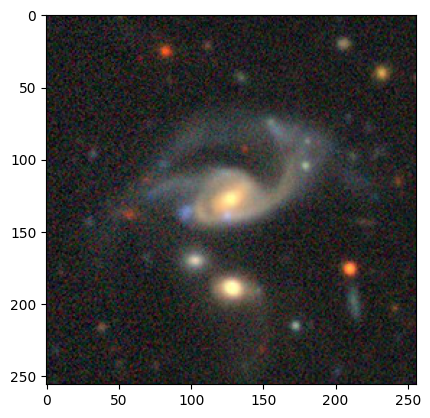

In [31]:
import matplotlib.pyplot as plt
plt.imshow(images[50]/255.0)


In [11]:
images[0].shape

(256, 256, 3)

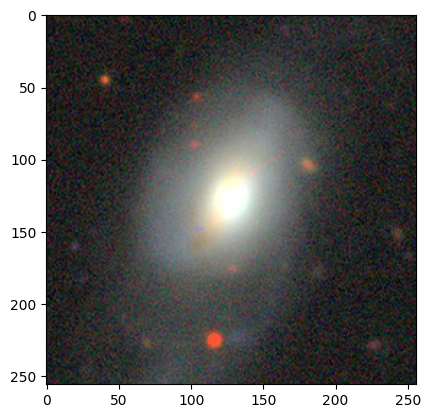

In [ ]:
import cv2

idx = 0
img = images[455]

# convert to uint8 if needed
if img.dtype != np.uint8:
    img = (img - img.min()) / (img.max() - img.min()) * 255
    img = img.astype(np.uint8)


# RGB → BGR for OpenCV
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

cv2.imshow("Galaxy", img_bgr)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [36]:
import numpy as np
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(np.arange(labels.shape[0]), test_size=0.1)
train_images, train_labels, test_images, test_labels = images[train_idx], labels[train_idx], images[test_idx], labels[test_idx]

((15962, 256, 256, 3), (15962, 10), (1774, 256, 256, 3), (1774, 10))

In [38]:
train_images.shape

(15962, 256, 256, 3)